<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/Stock_prediction/blob/main/StockPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Trading using Reinforcement Learning on NIFTY 50

## Objective
The goal of this project is to implement a reinforcement-learning-based
automated stock trading agent, following the formulation in:

**Deep Reinforcement Learning for Automated Stock Trading: An Ensemble Strategy**
(Yang et al., ICAIF 2020)

The agent is trained on Indian equity market data (NIFTY 50) and learns
direct portfolio allocation decisions under transaction costs and risk constraints.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
# Uninstall the conflicting old gym library
!pip uninstall -y gym

Found existing installation: gym 0.25.2
Uninstalling gym-0.25.2:
  Successfully uninstalled gym-0.25.2


In [3]:
# Install required packages
!pip install -q stable_baselines3
!pip install -q gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 1.9 MB/s eta 0:00:00


In [4]:
# 1. Standard Library Imports
import os
import time
import random
from datetime import datetime
from typing import List, Dict, Tuple, Any, Optional, Union

# 2. Data Science & Math
import numpy as np
import pandas as pd
import torch

# 3. Financial Data
import yfinance as yf

# 4. Reinforcement Learning
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO

# 5. Plotting & Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- Global Configuration ---
# Set the plotting style immediately after imports
sns.set_theme(style="whitegrid")

## Reproducibility
###To ensure consistent and repeatable results, all sources of randomness (NumPy, PyTorch, Python) are seeded.



In [5]:
SEED = 21

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# CONFIGURATION

In [6]:
CONFIG = {
    # Environment
    'INITIAL_BALANCE': 1_000_000,
    'H_MAX': 100,
    'TRANSACTION_COST_PCT': 0.001,

    # Training
    'TIMESTEPS_PER_TRAIN': 15_000,
    'WINDOW_SIZE_MONTHS': 3,

    # Dates
    'DATA_START': '2009-11-01',
    'TRAIN_START': '2010-01-01',
    'TRAIN_CUTOFF': '2015-12-31',
    'FINAL_END': '2020-01-01',

    # Metrics
    'RISK_FREE_RATE_ANNUAL': 0.06,

    # Model Parameters
    'PPO_PARAMS': {
        'learning_rate': 0.0005,
        'n_steps': 1024,
        'batch_size': 64,
        'n_epochs': 10,
        'ent_coef': 0.005,
        'clip_range': 0.2,
        'gamma': 0.99,
        'gae_lambda': 0.95,

        'policy_kwargs': {
            'net_arch': [128, 128]
        }
    }
}

# SECTION 1: DATA COLLECTION

In [7]:
nifty_2010_tickers = { "Infosys": "INFY.NS", "TCS": "TCS.NS",
                      "Wipro": "WIPRO.NS", "HCL Tech": "HCLTECH.NS",
                      "HDFC Bank": "HDFCBANK.NS", "ICICI Bank": "ICICIBANK.NS",
                      "SBI": "SBIN.NS", "Axis Bank": "AXISBANK.NS", "PNB": "PNB.NS",
                      "Bharti Airtel": "BHARTIARTL.NS", "Maruti Suzuki": "MARUTI.NS",
                      "M&M": "M&M.NS", "Hero MotoCorp": "HEROMOTOCO.NS","GAIL": "GAIL.NS",
                      "Idea Cellular": "IDEA.NS", "Reliance Ind": "RELIANCE.NS",
                      "ONGC": "ONGC.NS", "BPCL": "BPCL.NS", "ITC": "ITC.NS",
                      "L&T": "LT.NS", "Hindustan Unilever": "HINDUNILVR.NS",
                      "Tata Steel": "TATASTEEL.NS", "Hindalco": "HINDALCO.NS",
                      "Jindal Steel": "JINDALSTEL.NS", "SAIL": "SAIL.NS",
                      "NTPC": "NTPC.NS", "Power Grid": "POWERGRID.NS","BHEL": "BHEL.NS",
                      "Tata Power": "TATAPOWER.NS", "Reliance Power": "RPOWER.NS",
                      "Siemens": "SIEMENS.NS", "ABB India": "ABB.NS","Cipla": "CIPLA.NS",
                      "Reliance Infra": "RELINFRA.NS", "Suzlon": "SUZLON.NS", "ACC": "ACC.NS",
                      "Sun Pharma": "SUNPHARMA.NS", "Grasim": "GRASIM.NS", "DLF": "DLF.NS",
                       "Ambuja Cements": "AMBUJACEM.NS" }

In [8]:
def download_stock_data(
    tickers_dict: Dict[str, str],
    start_date: str,
    end_date: str,
    sleep_time: float = 0.01
) -> pd.DataFrame:
    """
    Downloads historical stock data for multiple companies with tracking, cleaning, and error handling.

    This function iterates through a dictionary of tickers, fetches data using yfinance,
    standardizes column names to lowercase, handles MultiIndex issues, and returns a
    consolidated DataFrame.

    Args:
        tickers_dict (Dict[str, str]): A dictionary mapping company names (keys) to
            stock ticker symbols (values). Example: {'Apple': 'AAPL', 'Google': 'GOOGL'}.
        start_date (str): The start date for data retrieval in 'YYYY-MM-DD' format.
        end_date (str): The end date for data retrieval in 'YYYY-MM-DD' format.
        sleep_time (float, optional): Seconds to pause between requests to prevent
            rate limiting. Defaults to 0.01.

    Returns:
        pd.DataFrame: A single DataFrame containing the combined historical data
            for all successfully downloaded stocks. Columns include:
            ['date', 'company_name', 'open', 'high', 'low', 'close', 'volume'].

    Raises:
        ValueError: If no data could be downloaded for any of the provided tickers.
    """
    frames = []
    failed = []

    print(f"Downloading data for {len(tickers_dict)} stocks...\n")

    for company_name, ticker in tickers_dict.items():
        try:
            dat = yf.Ticker(ticker).history(
                start=start_date,
                end=end_date,
                auto_adjust=True
            )

            if dat.empty:
                print(f"No data for {company_name}")
                failed.append(company_name)
                continue

            # Handle MultiIndex columns
            if isinstance(dat.columns, pd.MultiIndex):
                dat.columns = dat.columns.get_level_values(0)

            dat.reset_index(inplace=True)

            dat.rename(columns={
                'Date': 'date',
                'Open': 'open',
                'High': 'high',
                'Low': 'low',
                'Close': 'close',
                'Volume': 'volume'
            }, inplace=True)

            # Ensure timezone naive datetime
            dat['date'] = pd.to_datetime(dat['date']).dt.tz_localize(None)
            dat['company_name'] = company_name

            dat = dat[['date', 'company_name', 'open', 'high', 'low', 'close', 'volume']]

            frames.append(dat)

            time.sleep(sleep_time)

        except Exception as e:
            failed.append(company_name)
            print(f"Failed {company_name}: {e}")

    if not frames:
        raise ValueError("No data downloaded for any stock.")

    df = pd.concat(frames, ignore_index=True)

    print("\nData Summary")
    print("-" * 60)
    print(f"Downloaded stocks : {len(frames)}")
    print(f"Failed stocks     : {len(failed)}")

    if failed:
        print(f"Failed list       : {', '.join(failed)}")

    print(f"Total rows        : {len(df):,}")
    print(f"Date range        : {df['date'].min()} → {df['date'].max()}")
    print("-" * 60)

    return df

In [9]:
df = download_stock_data(
    nifty_2010_tickers,
    start_date="2009-11-01",
    end_date="2020-01-01"
)



Data Summary
------------------------------------------------------------
Downloaded stocks : 40
Failed stocks     : 0
Total rows        : 100,121
Date range        : 2009-11-03 00:00:00 → 2019-12-31 00:00:00
------------------------------------------------------------


# SECTION 2: DATA PREPROCESSING

In [10]:
df.sort_values(by='date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Calculate daily returns
df['daily_return'] = df.groupby('company_name')['close'].pct_change()

In [11]:
df.head()

,date,company_name,open,high,low,close,volume,daily_return
0,2009-11-03,Infosys,187.345696,191.113024,181.146203,182.247482,12042264,NaN
1,2009-11-03,Tata Power,103.968001,106.664338,99.169780,101.765091,5602408,NaN
2,2009-11-03,SBI,180.118029,180.118029,172.129258,173.199921,29840820,NaN
3,2009-11-03,Reliance Power,133.477874,141.560021,131.763480,133.183975,4041699,NaN
4,2009-11-03,Siemens,246.822842,255.452002,233.951420,240.266617,682288,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100121 entries, 0 to 100120
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          100121 non-null  datetime64[ns]
 1   company_name  100121 non-null  object        
 2   open          100121 non-null  float64       
 3   high          100121 non-null  float64       
 4   low           100121 non-null  float64       
 5   close         100121 non-null  float64       
 6   volume        100121 non-null  int64         
 7   daily_return  100081 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 6.1+ MB


# SECTION 3: TECHNICAL INDICATORS

Following the reference paper, the following indicators are computed
for each stock and included in the RL state space:

- MACD: momentum indicator
- RSI: overbought / oversold signal
- CCI: deviation from statistical mean
- ADX: trend strength

These indicators allow the agent to infer market dynamics beyond raw prices.


In [13]:
def ema(x: pd.Series, span: int) -> pd.Series:
    """
    Calculates the Exponential Moving Average (EMA).

    Args:
        x (pd.Series): The input data series (e.g., closing prices).
        span (int): The span (window size) for the EMA calculation.

    Returns:
        pd.Series: The exponentially weighted moving average.
    """
    # adjust=False calculates the EMA recursively
    return x.ewm(span=span, adjust=False).mean()

In [14]:
def rma(x: pd.Series, n: int) -> pd.Series:
    """
    Calculates the Running Moving Average (RMA), also known as Wilder's Smoothing.

    This is commonly used in RSI and ADX calculations.

    Args:
        x (pd.Series): The input data series.
        n (int): The period for the moving average.

    Returns:
        pd.Series: The Wilder's smoothed average.
    """
    # Wilder's smoothing is equivalent to an EMA with alpha = 1/n
    return x.ewm(alpha=1/n, adjust=False).mean()

In [15]:
def macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9) -> pd.Series:
    """
    Calculates the MACD Histogram (momentum indicator).

    The MACD Histogram represents the distance between the MACD line and the Signal line.

    Args:
        close (pd.Series): Series of closing prices.
        fast (int, optional): The short-term EMA period. Defaults to 12.
        slow (int, optional): The long-term EMA period. Defaults to 26.
        signal (int, optional): The signal line EMA period. Defaults to 9.

    Returns:
        pd.Series: The MACD Histogram values (MACD Line - Signal Line).
    """
    macd_line = ema(close, fast) - ema(close, slow)
    signal_line = ema(macd_line, signal)

    # Returning the histogram (the difference)
    return macd_line - signal_line

In [16]:
def rsi(close: pd.Series, period: int = 14) -> pd.Series:
    """
    Calculates the Relative Strength Index (RSI).

    RSI measures the speed and change of price movements, oscillating between 0 and 100.

    Args:
        close (pd.Series): Series of closing prices.
        period (int, optional): The lookback period. Defaults to 14.

    Returns:
        pd.Series: The RSI values (0-100).
    """
    delta = close.diff()

    # Separate gains and losses
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)  # Make losses positive for calculation

    # Calculate smoothed averages using RMA (Wilder's method)
    avg_gain = rma(gain, period)
    avg_loss = rma(loss, period)

    # Calculate RS and RSI
    # Added 1e-8 to avoid division by zero errors
    rs = avg_gain / (avg_loss + 1e-8)
    return 100 - (100 / (1 + rs))

In [17]:
def cci(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 20) -> pd.Series:
    """
    Calculates the Commodity Channel Index (CCI).

    CCI measures the difference between the current price and the historical average price.

    Args:
        high (pd.Series): Series of high prices.
        low (pd.Series): Series of low prices.
        close (pd.Series): Series of closing prices.
        period (int, optional): The window size for the moving average. Defaults to 20.

    Returns:
        pd.Series: The CCI values.
    """
    # Typical Price (TP)
    tp = (high + low + close) / 3

    # Simple Moving Average (SMA) of TP
    sma = tp.rolling(period).mean()

    # Mean Absolute Deviation (MAD)
    mad = (tp - sma).abs().rolling(period).mean()

    # CCI Formula: (TP - SMA) / (0.015 * MAD)
    return (tp - sma) / (0.015 * mad + 1e-8)

In [18]:
def adx(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    """
    Calculates the Average Directional Index (ADX).

    ADX quantifies the strength of a trend regardless of its direction.

    Args:
        high (pd.Series): Series of high prices.
        low (pd.Series): Series of low prices.
        close (pd.Series): Series of closing prices.
        period (int, optional): The smoothing period. Defaults to 14.

    Returns:
        pd.Series: The ADX values (0-100).
    """
    plus_dm = high.diff()
    minus_dm = low.diff()

    # Directional Movement logic
    # +DM is valid if High moved up more than Low moved down
    plus_dm = np.where((plus_dm > minus_dm) & (plus_dm > 0), plus_dm, 0.0)

    # -DM is valid if Low moved down more than High moved up
    # Note: Logic here handles the negative diffs specifically
    minus_dm = np.where((minus_dm > plus_dm) & (minus_dm > 0), -minus_dm, 0.0)

    plus_dm = pd.Series(plus_dm, index=high.index)
    minus_dm = pd.Series(minus_dm, index=high.index)

    # True Range (TR) Calculation
    tr1 = high - low
    tr2 = (high - close.shift()).abs()
    tr3 = (low - close.shift()).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    # Smoothed True Range and Directional Movements
    atr = rma(tr, period)
    plus_di = 100 * rma(plus_dm, period) / (atr + 1e-8)
    minus_di = 100 * rma(minus_dm, period) / (atr + 1e-8)

    # Directional Index (DX)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-8)

    # ADX is the smoothed DX
    return rma(dx, period)

In [19]:
def calculate_ta_indicators(group: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates technical analysis indicators (MACD, RSI, CCI, ADX) for a single stock.

    This function sorts the data by date to ensure time-series calculations are correct,
    then computes momentum, trend, and volatility indicators using the helper functions
    defined previously.

    Args:
        group (pd.DataFrame): A DataFrame containing historical data for a single stock.
            Must contain columns: ['date', 'high', 'low', 'close'].

    Returns:
        pd.DataFrame: A copy of the input DataFrame with four new columns appended:
            ['MACD', 'RSI', 'CCI', 'ADX'].
    """
    # Sort by date to ensure sequential calculations
    group = group.sort_values('date').copy()

    # Apply technical indicators
    group['MACD'] = macd(group['close'])
    group['RSI']  = rsi(group['close'])
    group['CCI']  = cci(group['high'], group['low'], group['close'])
    group['ADX']  = adx(group['high'], group['low'], group['close'])

    return group

In [20]:
df_with_indicators = (
    df
    .groupby('company_name', group_keys=False)
    .apply(calculate_ta_indicators)
    .reset_index(level=0)
)

In [21]:
final_data = df_with_indicators[df_with_indicators['date'] >= '2010-01-01'].copy()
final_data.dropna(inplace=True)

required_columns = [
    'date', 'company_name', 'close',
    'daily_return', 'MACD', 'RSI', 'CCI', 'ADX'
]

final_data = final_data[required_columns]

final_data.sort_values(['date', 'company_name'], inplace=True)
final_data.reset_index(drop=True, inplace=True)

print(f"Final data shape: {final_data.shape}")
print(f"Date range: {final_data['date'].min()} to {final_data['date'].max()}")


Final data shape: (98481, 8)
Date range: 2010-01-04 00:00:00 to 2019-12-31 00:00:00


# SECTION 4: TURBULENCE CALCULATION

In [22]:
def calculate_turbulence_vectorized(
    df: pd.DataFrame,
    reference_df: pd.DataFrame | None = None
) -> tuple[np.ndarray, float]:
    """
    Calculates financial turbulence (Mahalanobis distance) using vectorized operations.

    Turbulence measures the degree of unusual correlation behavior in the market.
    It compares the current returns against a historical mean and covariance matrix.

    If 'reference_df' is provided (recommended), the mean and covariance are derived
    from that history to prevent data leakage (lookahead bias).

    Args:
        df (pd.DataFrame): The current data to analyze. Must contain columns:
            ['date', 'company_name', 'daily_return'].
        reference_df (pd.DataFrame, optional): Historical data used to establish the
            baseline mean and covariance. If None, the function calculates
            statistics from 'df' itself. Defaults to None.

    Returns:
        tuple[np.ndarray, float]:
            - turbulence: An array of shape (T,) containing turbulence values for each date.
            - threshold: The 99.5th percentile turbulence value (scalar).
    """

    def pivot_returns(x: pd.DataFrame) -> pd.DataFrame:
        """Helper to pivot data into a (Date x Stock) matrix."""
        return (
            x.pivot(index='date', columns='company_name', values='daily_return')
             .sort_index(axis=1)
        )

    # Transform current data into a matrix (Rows=Time, Cols=Stocks)
    X = pivot_returns(df)

    if reference_df is not None:
        # Use reference data for statistics (No Leakage)
        X_ref = pivot_returns(reference_df)

        # distinct stocks might exist in different sets, align them
        common_assets = X.columns.intersection(X_ref.columns)
        X = X[common_assets]
        X_ref = X_ref[common_assets]

        # Calculate baseline statistics from Reference Data
        X_ref = X_ref.dropna()
        mu = X_ref.mean().values
        cov = X_ref.cov().values

        # Fill missing current data with 0 (assuming neutral return if data missing)
        X = X.fillna(0.0)
    else:
        # Use self-statistics (Leakage Risk if testing)
        X = X.dropna()
        mu = X.mean().values
        cov = X.cov().values

    # Inverse Covariance Matrix (Precision Matrix)
    # pinned pseudo-inverse handles singular matrices better than standard inv
    cov_inv = np.linalg.pinv(cov)

    # Centralize the data (demean)
    D = X.values - mu

    # Calculate Mahalanobis distance: (x - mu) * cov_inv * (x - mu)^T
    # We only need the diagonal elements (distance for each time step t)
    # einsum 'ij,jk,ik->i' does this efficiently:
    # i = time steps, j = assets (first mult), k = assets (second mult)
    turbulence = np.einsum(
        'ij,jk,ik->i', D, cov_inv, D
    )

    # Calculate 99.5% Threshold
    if reference_df is not None:
        # Threshold should be based on what was considered "normal" in the past
        D_ref = X_ref.values - mu
        ref_turbulence = np.einsum(
            'ij,jk,ik->i', D_ref, cov_inv, D_ref
        )
        threshold = np.quantile(ref_turbulence, 0.995)
    else:
        threshold = np.quantile(turbulence, 0.995)

    return turbulence, threshold

# SECTION 5: TRADING ENVIRONMENT

### 3. Environment Formulation (OpenAI Gym)

We define a custom trading environment where the agent observes the state $s_t$ and executes actions $a_t$ to maximize cumulative rewards.

* **State Space ($s_t \in \mathbb{R}^{D}$):** A vector containing:
    * Balance $b_t$ and Portfolio Value.
    * Holdings vector $h_t$ (shares owned per stock).
    * Closing Prices vector $p_t$.
    * Technical Indicators matrix $X_t$ (MACD, RSI, CCI, ADX).

* **Action Space ($a_t \in [-1, 1]^N$):** A continuous vector where $a_{t,i}$ represents the proportion of shares to buy (positive) or sell (negative).

* **Reward Function ($r_t$):** The change in portfolio value minus transaction costs $c_t$ (where cost rate $\lambda = 0.1\%$):

$$
r_t = \underbrace{(b_{t+1} + p_{t+1}^T h_{t+1})}_{\text{New Value}} - \underbrace{(b_{t} + p_{t}^T h_{t})}_{\text{Old Value}} - c_t
$$

In [23]:
class StockTradingEnv(gym.Env):
    """
    A custom OpenAI Gym environment for stock trading simulation using Deep Reinforcement Learning.

    This environment simulates stock trading based on historical data and technical indicators.
    It supports 'panic selling' based on a turbulence index (financial instability metric).

    Attributes:
        df (pd.DataFrame): The source dataframe containing price and technical indicator data.
        action_space (gym.spaces.Box): Continuous space [-1, 1] representing the fraction
            of shares to buy (positive) or sell (negative).
        observation_space (gym.spaces.Box): Continuous space representing the state vector
            (balance, prices, holdings, technical indicators).
    """
    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        df: pd.DataFrame,
        turbulence_array: np.ndarray | List[float],
        turbulence_threshold: float,
        initial_balance: float,
        initial_holdings: Optional[np.ndarray] = None,
        h_max: int = 5000,
        transaction_cost_pct: float = 0.001,
        norm_dict: Optional[Dict[str, float]] = None,
    ):
        """
        Initializes the trading environment.

        Args:
            df (pd.DataFrame): Dataframe with columns:
                ['date', 'company_name', 'close', 'MACD', 'RSI', 'CCI', 'ADX'].
            turbulence_array (np.ndarray | List[float]): Array of turbulence values matching
                the unique dates in df.
            turbulence_threshold (float): Value above which the agent forces a sell-off
                (panic mode).
            initial_balance (float): Starting cash amount.
            initial_holdings (Optional[np.ndarray]): Initial share counts per stock.
                Defaults to 0 for all if None.
            h_max (int, optional): Maximum number of shares to trade per action.
                Defaults to 5000.
            transaction_cost_pct (float, optional): Trading fee percentage (e.g., 0.001 for 0.1%).
                Defaults to 0.001.
            norm_dict (Optional[Dict[str, float]], optional): Dictionary of normalization
                constants for the observation space. If None, calculated from data.
        """
        super().__init__()

        self.df = df.copy()
        self.turbulence_array = turbulence_array
        self.turbulence_threshold = turbulence_threshold

        self.initial_balance = initial_balance
        self.initial_holdings = initial_holdings
        self.h_max = h_max
        self.transaction_cost_pct = transaction_cost_pct
        self.norm_dict = norm_dict

        self.unique_dates = sorted(self.df["date"].unique())
        self.companies = sorted(self.df["company_name"].unique())
        self.stock_dim = len(self.companies)

        if len(self.turbulence_array) != len(self.unique_dates):
            raise ValueError("Turbulence length mismatch: Array length must match unique dates count.")

        self.feature_cols = ["close", "MACD", "RSI", "CCI", "ADX"]
        self._prepare_data()

        # State dimension:
        # 1 (Balance) + StockDim (Prices) + StockDim (Holdings) + StockDim * 4 (Indicators)
        self.state_dim = 1 + self.stock_dim * 6

        # Action: [-1, 1] for each stock
        self.action_space = spaces.Box(
            low=-1, high=1, shape=(self.stock_dim,), dtype=np.float32
        )

        # Observation: Infinite bounds (normalized values)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.state_dim,), dtype=np.float32
        )

        self.reset()

    def _prepare_data(self) -> None:
        """
        Preprocesses the dataframe into a 3D numpy array for fast access.

        Structure: (Time Steps, Stocks, Features)
        Also calculates normalization statistics if norm_dict was not provided.
        """
        idx = pd.MultiIndex.from_product(
            [self.unique_dates, self.companies],
            names=["date", "company_name"],
        )

        df = self.df.set_index(["date", "company_name"]).reindex(idx)

        for col in self.feature_cols:
            if col == "close":
                # Fill missing prices with previous, then next valid observation
                df[col] = df.groupby(level="company_name")[col].ffill().bfill()
            else:
                # Fill missing indicators with 0
                df[col] = df[col].fillna(0)

        df = df.reset_index()

        # Convert to 3D Array: [Days, Stocks, Features]
        self.data = df[self.feature_cols].values.reshape(
            len(self.unique_dates),
            self.stock_dim,
            len(self.feature_cols),
        )

        if self.norm_dict is None:
            flat = self.data.reshape(-1, len(self.feature_cols))
            self.norm = {
                "price_mean": flat[:, 0].mean(),
                "price_std": flat[:, 0].std() + 1e-8,
                "macd_mean": flat[:, 1].mean(),
                "macd_std": flat[:, 1].std() + 1e-8,
                "rsi_mean": 50.0,
                "rsi_std": 30.0,
                "cci_mean": 0.0,
                "cci_std": 100.0,
                "adx_mean": 25.0,
                "adx_std": 20.0,
                "balance_scale": self.initial_balance,
            }
        else:
            self.norm = self.norm_dict

    def _get_observation(self) -> np.ndarray:
        """
        Constructs the observation vector for the current time step.

        The observation includes:
        1. Normalized Balance
        2. Normalized Stock Prices
        3. Normalized Holdings (Shares / h_max)
        4. Normalized Technical Indicators (MACD, RSI, CCI, ADX)

        Returns:
            np.ndarray: Flattened observation vector of shape (state_dim,).
        """
        d = self.data[self.day]
        prices, macd, rsi, cci, adx = d.T
        n = self.norm

        obs = np.hstack(
            [
                [self.balance / n["balance_scale"]],
                (prices - n["price_mean"]) / n["price_std"],
                self.holdings / self.h_max,
                (macd - n["macd_mean"]) / n["macd_std"],
                (rsi - n["rsi_mean"]) / n["rsi_std"],
                (cci - n["cci_mean"]) / n["cci_std"],
                (adx - n["adx_mean"]) / n["adx_std"],
            ]
        )

        return obs.astype(np.float32)

    def reset(
        self,
        seed: Optional[int] = None,
        options: Optional[Dict[str, Any]] = None
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        """
        Resets the environment to the initial state.

        Args:
            seed (Optional[int]): Random seed for reproducibility.
            options (Optional[Dict]): Additional options (unused in this implementation).

        Returns:
            Tuple[np.ndarray, Dict]: The initial observation and an empty info dictionary.
        """
        super().reset(seed=seed)

        if seed is not None:
            np.random.seed(seed)

        self.day = 0
        self.balance = self.initial_balance

        self.holdings = (
            self.initial_holdings.copy()
            if self.initial_holdings is not None
            else np.zeros(self.stock_dim)
        )

        prices = self.data[self.day][:, 0]
        self.portfolio_value = self.balance + np.sum(self.holdings * prices)

        self.cash_memory = [self.balance]
        self.asset_memory = [self.portfolio_value]

        return self._get_observation(), {}

    def step(self, actions: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, Dict[str, Any]]:
        """
        Executes one time step within the environment.

        Logic:
        1. Checks for high market turbulence. If high, sells all holdings ("Panic Sell").
        2. Otherwise, processes Sell actions first to free up cash, then Buy actions.
        3. Updates balance, holdings, and portfolio value.
        4. Calculates reward based on portfolio value change.

        Args:
            actions (np.ndarray): Action vector from the agent. Values are [-1, 1].
                - Negative: Sell fraction of h_max.
                - Positive: Buy fraction of h_max.

        Returns:
            Tuple containing:
            - observation (np.ndarray): New state vector.
            - reward (float): Scaled change in portfolio value.
            - terminated (bool): Whether the episode has ended (end of data).
            - truncated (bool): Always False in this implementation.
            - info (Dict): Empty dictionary for auxiliary info.
        """
        # Check if we reached the end of the dataset
        if self.day >= len(self.unique_dates) - 1:
            return self._get_observation(), 0.0, True, False, {}

        prices = self.data[self.day][:, 0]
        prev_value = self.portfolio_value

        # --- Turbulence Logic ---
        if self.turbulence_array[self.day] > self.turbulence_threshold:
            # Panic Sell: Liquidate all assets
            revenue = np.sum(self.holdings * prices)
            cost = revenue * self.transaction_cost_pct
            self.balance += revenue - cost
            self.holdings[:] = 0
        else:
            # Normal Trading Logic
            actions = np.clip(actions, -1, 1)
            delta_shares = (actions * self.h_max).astype(int)

            # 1. Process SELLS first (to generate cash)
            # np.where returns indices where condition is true
            sell_indices = np.where(delta_shares < 0)[0]
            for i in sell_indices:
                # Can't sell more than we own
                shares = min(abs(delta_shares[i]), self.holdings[i])
                if shares > 0:
                    revenue = shares * prices[i]
                    cost = revenue * self.transaction_cost_pct
                    self.balance += revenue - cost
                    self.holdings[i] -= shares

            # 2. Process BUYS second
            buy_indices = np.where(delta_shares > 0)[0]
            usable_cash = self.balance * 0.99 # Safety buffer

            for i in buy_indices:
                # Calculate max affordable shares including transaction cost
                max_shares = usable_cash // (prices[i] * (1 + self.transaction_cost_pct))
                allowed_shares = max(0, max_shares)

                # Buy requested amount or max affordable
                shares = min(delta_shares[i], allowed_shares)
                if shares <= 0:
                    continue

                trade_value = shares * prices[i]
                fee = trade_value * self.transaction_cost_pct
                total_cost = trade_value + fee

                if usable_cash >= total_cost:
                    self.balance -= total_cost
                    usable_cash -= total_cost
                    self.holdings[i] += shares

        # Move to next day
        self.day += 1
        new_prices = self.data[self.day][:, 0]
        self.portfolio_value = self.balance + np.sum(self.holdings * new_prices)
        self.asset_memory.append(self.portfolio_value)
        self.cash_memory.append(self.balance)

        # Reward: Change in portfolio value (scaled down)
        reward = (self.portfolio_value - prev_value) * 1e-4

        # Check termination
        done = self.day == len(self.unique_dates) - 1

        if done:
            # Liquidate everything at end of episode to get final value
            revenue = np.sum(self.holdings * new_prices)
            cost = revenue * self.transaction_cost_pct
            self.balance += revenue - cost
            self.holdings[:] = 0
            self.portfolio_value = self.balance
            self.asset_memory.append(self.portfolio_value)

        # Return standard Gym tuple: (obs, reward, terminated, truncated, info)
        return self._get_observation(), reward, done, False, {}

# SECTION 6: HELPER FUNCTIONS FOR ROLLING WINDOW

In [24]:
def get_rolling_dates(
    start_date: str,
    end_date: str,
    freq: str = '3ME'
) -> pd.DatetimeIndex:
    """
    Generates a sequence of dates to be used as checkpoints for rolling window training.

    This function creates a DatetimeIndex from start to end with the specified frequency.
    It ensures the exact 'end_date' is included in the list, even if the frequency
    steps don't naturally land on it.

    Args:
        start_date (str): The overall start date (e.g., '2015-01-01').
        end_date (str): The overall end date (e.g., '2023-01-01').
        freq (str, optional): The pandas frequency alias for the window size.
            Defaults to '3ME' (3 Months End).

    Returns:
        pd.DatetimeIndex: An index containing the start dates for each rolling window segment.
    """
    dates = pd.date_range(start=start_date, end=end_date, freq=freq)

    # Ensure the final end_date is included if not covered by the range
    if dates.empty or dates[-1] < pd.Timestamp(end_date):
        dates = pd.DatetimeIndex(list(dates) + [pd.Timestamp(end_date)])

    return dates

In [25]:
def prepare_dataframe_for_window(
    df_raw: pd.DataFrame,
    start_date: Union[str, pd.Timestamp],
    end_date: Union[str, pd.Timestamp],
    all_companies: List[str]
) -> pd.DataFrame:
    """
    Prepares and cleans a data slice for a specific time window.

    This function performs crucial data alignment for machine learning:
    1. Filters data to the specific time window.
    2. Reindexes the data to ensure EVERY company appears on EVERY date (Cartesian product).
       This prevents dimension mismatch errors in RL environments.
    3. Fills missing values:
       - Prices ('close') use Forward Fill then Backward Fill.
       - Technical indicators use 0.

    Args:
        df_raw (pd.DataFrame): The complete master dataframe.
        start_date (Union[str, pd.Timestamp]): Start of the current window.
        end_date (Union[str, pd.Timestamp]): End of the current window.
        all_companies (List[str]): Complete list of unique company tickers to enforce
            consistency across the window.

    Returns:
        pd.DataFrame: A clean, sorted, and fully populated dataframe ready for the environment.
    """
    # Filter for the specific date range
    df_window = df_raw[(df_raw['date'] >= start_date) & (df_raw['date'] <= end_date)].copy()

    if df_window.empty:
        return pd.DataFrame()

    unique_dates = sorted(df_window['date'].unique())

    # Create the "Perfect Index" (All Dates x All Companies)
    complete_idx = pd.MultiIndex.from_product(
        [unique_dates, all_companies],
        names=['date', 'company_name']
    )

    # Reindex the data to match the perfect index
    # This inserts rows with NaN for any missing company/date combinations
    df_indexed = df_window.set_index(['date', 'company_name'])
    df_complete = df_indexed.reindex(complete_idx)

    # Imputation Strategy
    feature_cols = ['close', 'MACD', 'RSI', 'CCI', 'ADX', 'daily_return']
    for col in feature_cols:
        if col == 'close':
            # Price must be continuous: fill forward (yesterday's price), then backward
            df_complete[col] = df_complete.groupby(level='company_name')[col].ffill().bfill()
        else:
            # Indicators can be 0 (neutral) if data is missing
            df_complete[col] = df_complete[col].fillna(0)

    df_complete = df_complete.reset_index()
    df_complete.sort_values(['date', 'company_name'], inplace=True)

    return df_complete

# SECTION 7: ROLLING WINDOW TRAINING



To prevent look-ahead bias, we employ a **Rolling Window** strategy. The model trains on a historical window (e.g., $t_{start}$ to $t_{end}$) and validates on the subsequent quarter ($t_{end}$ to $t_{end} + \Delta t$).

> **Risk Management (Turbulence Index $d_t$):**
> We calculate the Mahalanobis distance to detect extreme market anomalies. Let $y_t$ be the asset returns, $\mu$ be the mean, and $\Sigma$ be the covariance matrix:
>
> $$d_t = (y_t - \mu)^T \Sigma^{-1} (y_t - \mu)$$
>
> **Condition:** If $d_t > \theta$ (where $\theta$ is the 99th percentile of historical turbulence), the agent executes a "Safety" action:
>
> $$a_t \rightarrow \text{Sell All} \quad (\forall i, h_{t+1, i} = 0)$$

In [26]:
all_companies = sorted(final_data['company_name'].unique())

# Generate rolling dates
rolling_split_dates = get_rolling_dates(CONFIG['TRAIN_CUTOFF'], CONFIG['FINAL_END'], freq='3ME')

model = None
current_train_end = pd.Timestamp(CONFIG['TRAIN_CUTOFF'])

all_portfolio_values = []
all_dates = []
all_cash_values = [] # Initialize all_cash_values
model_save_path = "ppo_stock_agent"

# Keep track of holdings between windows
current_holdings = None

In [27]:
for i in range(len(rolling_split_dates) - 1):
    test_start = current_train_end + pd.Timedelta(days=1)
    test_end = rolling_split_dates[i+1]

    if test_start >= pd.Timestamp(CONFIG['FINAL_END']):
        break

    print(f"\n{'='*60}")
    print(f"ITERATION {i+1}")
    print(f"Training: {CONFIG['TRAIN_START']} to {current_train_end.date()}")
    print(f"Trading:  {test_start.date()} to {test_end.date()}")
    print(f"{'='*60}")

    # === TRAINING PHASE ===
    train_df = prepare_dataframe_for_window(
        final_data,
        pd.Timestamp(CONFIG['TRAIN_START']),
        current_train_end,
        all_companies
    )

    if train_df.empty:
        print("Warning: Training data empty, skipping")
        current_train_end = test_end
        continue

    # Calculate turbulence for training period
    train_turbulence, train_threshold = calculate_turbulence_vectorized(train_df)

    # Create training environment
    env_train = StockTradingEnv(
        df=train_df,
        turbulence_array=train_turbulence,
        turbulence_threshold=train_threshold,
        initial_balance=CONFIG['INITIAL_BALANCE'],
        h_max=CONFIG['H_MAX'],
        norm_dict=None
    )

    # Train model
    if model is None:
        model = PPO(
            "MlpPolicy",
            env_train,
            verbose=0,
            seed = SEED,
            **CONFIG['PPO_PARAMS']
        )
    else:
        model.set_env(env_train)

    print("Training model...")
    model.learn(total_timesteps=CONFIG['TIMESTEPS_PER_TRAIN'], progress_bar=False)
    model.save(model_save_path)

    # === TRADING PHASE ===
    trade_df = prepare_dataframe_for_window(
        final_data,
        test_start,
        test_end,
        all_companies
    )

    if trade_df.empty:
        print("Warning: Trading data empty, skipping")
        if all_portfolio_values:
            all_portfolio_values.append(all_portfolio_values[-1])
            all_dates.append(test_end)
            all_cash_values.append(all_cash_values[-1]) # Keep cash value consistent
        current_train_end = test_end
        continue

    # Calculate trading turbulence (using training data as reference to avoid leakage)
    trade_turbulence, trade_threshold = calculate_turbulence_vectorized(
        trade_df,
        reference_df=train_df
    )

    # Carry forward balance from previous window
    if all_portfolio_values:
        initial_balance_trade = all_portfolio_values[-1]
        initial_holdings_trade = None # Assumption: Portfolio is liquidated between windows
    else:
        initial_balance_trade = CONFIG['INITIAL_BALANCE']
        initial_holdings_trade = None

    # Create trading environment

    env_trade = StockTradingEnv(
        df=trade_df,
        turbulence_array=trade_turbulence,
        turbulence_threshold=train_threshold,
        initial_balance=initial_balance_trade,
        initial_holdings=initial_holdings_trade,
        h_max=CONFIG['H_MAX'],
        norm_dict=env_train.norm
    )


    print("Running trading simulation...")
    obs, _ = env_trade.reset(SEED)
    done = False

    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_trade.step(action)
        done = terminated or truncated

    # Collect results
    window_memory = env_trade.asset_memory
    window_cash = env_trade.cash_memory
    window_dates = sorted(trade_df['date'].unique())

    # Append to global records
    if all_portfolio_values:
        all_portfolio_values.extend(window_memory[1:])
        all_dates.extend(window_dates[1:])
        all_cash_values.extend(window_cash[1:])
    else:
        all_portfolio_values.extend(window_memory)
        all_dates.extend(window_dates)
        all_cash_values.extend(window_cash)

    print(f"Window Final Portfolio Value: ₹{window_memory[-1]:,.2f}")
    if initial_balance_trade > 0:
        win_ret = ((window_memory[-1] / initial_balance_trade) - 1) * 100
        print(f"Window Return: {win_ret:.2f}%")

    # Update for next iteration
    current_train_end = test_end


ITERATION 1
Training: 2010-01-01 to 2015-12-31
Trading:  2016-01-01 to 2016-03-31
Training model...
Running trading simulation...
Window Final Portfolio Value: ₹1,006,606.23
Window Return: 0.66%

ITERATION 2
Training: 2010-01-01 to 2016-03-31
Trading:  2016-04-01 to 2016-06-30
Training model...
Running trading simulation...
Window Final Portfolio Value: ₹1,138,331.49
Window Return: 13.09%

ITERATION 3
Training: 2010-01-01 to 2016-06-30
Trading:  2016-07-01 to 2016-09-30
Training model...
Running trading simulation...
Window Final Portfolio Value: ₹1,205,441.92
Window Return: 5.90%

ITERATION 4
Training: 2010-01-01 to 2016-09-30
Trading:  2016-10-01 to 2016-12-31
Training model...
Running trading simulation...
Window Final Portfolio Value: ₹1,141,644.94
Window Return: -5.29%

ITERATION 5
Training: 2010-01-01 to 2016-12-31
Trading:  2017-01-01 to 2017-03-31
Training model...
Running trading simulation...
Window Final Portfolio Value: ₹1,307,587.30
Window Return: 14.54%

ITERATION 6
Trai

# SECTION 8: VISUALIZATION AND METRICS


## 8.1: MAJOR MARKET EVENTS (2016–2019)

In [28]:
MAJOR_EVENTS = [
    {
        'date': '2016-11-08',
        'name': 'Demonetization',
        'description': '₹500 & ₹1000 notes invalidated (86% of currency)',
        'impact': 'NIFTY fell ~6% in two sessions',
        'color': '#E63946'
    },
    {
        'date': '2017-07-01',
        'name': 'GST Rollout',
        'description': 'Unified indirect tax system',
        'impact': 'Short-term disruption, sectoral divergence',
        'color': '#F77F00'
    },
    {
    'date': '2018-02-14',
    'name': 'PNB–Nirav Modi Scam',
    'description': '₹13,000+ crore fraud involving Punjab National Bank',
    'impact': 'Banking stocks fell sharply; PSU banks underperformed for months',
    'color': '#6A4C93'
    },
    {
        'date': '2019-09-20',
        'name': 'Corporate Tax Cut',
        'description': 'Tax slashed from 30% → 22%',
        'impact': 'NIFTY jumped ~8% in one session',
        'color': '#06A77D'
    }

]

# 8.2: DATA PREPARATION

In [29]:
# --- Agent portfolio ---
min_len = min(len(all_dates), len(all_portfolio_values))
df_agent = pd.DataFrame({
    'date': pd.to_datetime(all_dates[:min_len]).normalize(),
    'value': all_portfolio_values[:min_len]
})

# --- NIFTY benchmark (using existing downloader) ---
start = df_agent['date'].min().strftime('%Y-%m-%d')
end = (df_agent['date'].max() + pd.Timedelta(days=5)).strftime('%Y-%m-%d')

nifty_raw = download_stock_data(
    tickers_dict={"NIFTY 50": "^NSEI"},
    start_date=start,
    end_date=end,
    sleep_time=0.01
)

nifty_prices = nifty_raw[['date', 'close']].copy()

df_nifty = pd.merge(df_agent[['date']], nifty_prices, on='date', how='left')
df_nifty['close'] = df_nifty['close'].ffill().bfill()
df_nifty['value'] = (
    df_nifty['close'] / df_nifty['close'].iloc[0]
) * CONFIG['INITIAL_BALANCE']
df_nifty = df_nifty[['date', 'value']]

# --- Buy & Hold benchmark ---
prices = final_data.pivot(index='date', columns='company_name', values='close')
prices = prices.reindex(df_agent['date']).ffill().bfill()

capital_per_stock = CONFIG['INITIAL_BALANCE'] / prices.shape[1]
shares = capital_per_stock / (prices.iloc[0] + 1e-8)

df_buyhold = pd.DataFrame({
    'date': df_agent['date'],
    'value': (prices * shares).sum(axis=1).values
})



Data Summary
------------------------------------------------------------
Downloaded stocks : 1
Failed stocks     : 0
Total rows        : 981
Date range        : 2016-01-04 00:00:00 → 2020-01-03 00:00:00
------------------------------------------------------------


# 8.3: PERFORMANCE METRICS

In [30]:
def calculate_performance_metrics(df, initial_balance, rf_annual):
    df = df.copy()
    df['daily_return'] = df['value'].pct_change()

    final_value = df['value'].iloc[-1]
    total_return = (final_value - initial_balance) / initial_balance * 100

    mean_ret = df['daily_return'].mean()
    std_ret = df['daily_return'].std()

    sharpe = (
        ((mean_ret - rf_annual / 252) / std_ret) * np.sqrt(252)
        if std_ret > 0 else 0.0
    )

    rolling_max = df['value'].cummax()
    drawdown = (df['value'] - rolling_max) / rolling_max
    max_dd = drawdown.min() * 100

    volatility = std_ret * np.sqrt(252) * 100

    return final_value, total_return, sharpe, max_dd, volatility


metrics = {
    'PPO Agent': calculate_performance_metrics(df_agent, CONFIG['INITIAL_BALANCE'], CONFIG['RISK_FREE_RATE_ANNUAL']),
    'NIFTY 50': calculate_performance_metrics(df_nifty, CONFIG['INITIAL_BALANCE'], CONFIG['RISK_FREE_RATE_ANNUAL']),
    'Buy & Hold (Equal Wt)': calculate_performance_metrics(df_buyhold, CONFIG['INITIAL_BALANCE'], CONFIG['RISK_FREE_RATE_ANNUAL'])
}

print("\n" + "="*110)
print(f"{'STRATEGY':<25} | {'FINAL VALUE':<15} | {'RETURN':<10} | {'SHARPE':<8} | {'MAX DD':<10} | {'VOLATILITY':<10}")
print("-"*110)
for k, v in metrics.items():
    print(
        f"{k:<25} | ₹{v[0]:>14,.2f} | {v[1]:>9.2f}% | {v[2]:>8.2f} | {v[3]:>9.2f}% | {v[4]:>9.2f}%"
    )
print("="*110)



STRATEGY                  | FINAL VALUE     | RETURN     | SHARPE   | MAX DD     | VOLATILITY
--------------------------------------------------------------------------------------------------------------
PPO Agent                 | ₹  1,729,865.35 |     72.99% |     0.61 |    -22.91% |     15.62%
NIFTY 50                  | ₹  1,561,799.76 |     56.18% |     0.50 |    -14.55% |     13.00%
Buy & Hold (Equal Wt)     | ₹  1,322,603.69 |     32.26% |     0.16 |    -24.32% |     16.21%


##8.4: PLOT 1 — SIMPLE PERFORMANCE COMPARISON

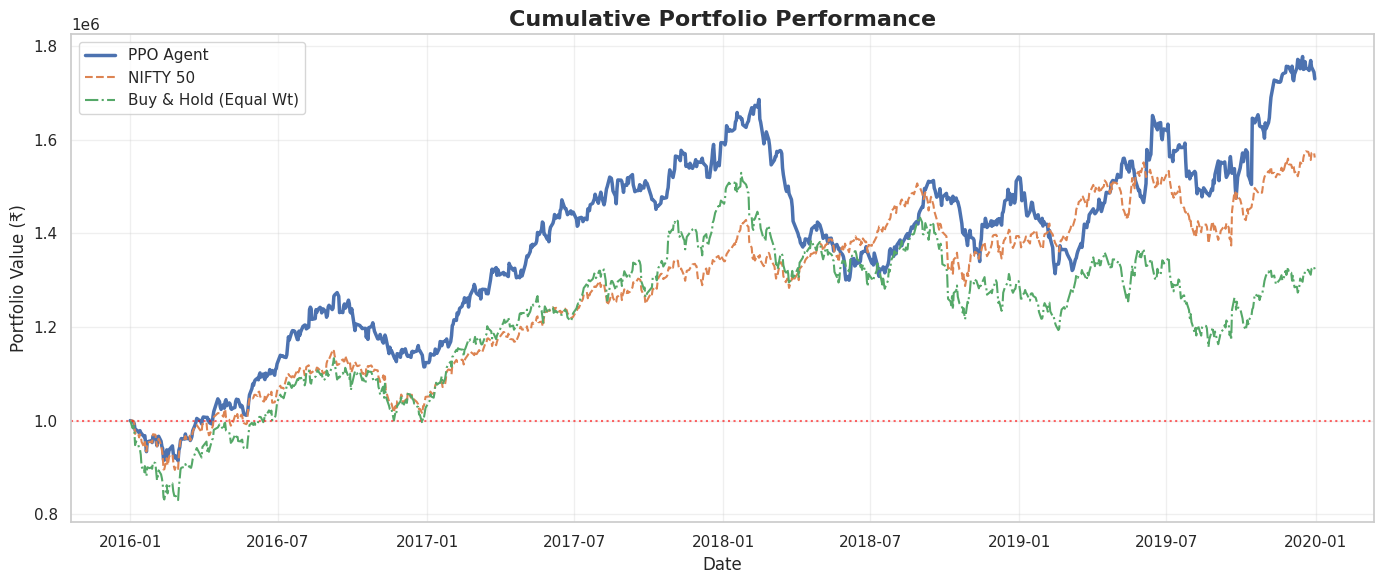

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(df_agent['date'], df_agent['value'], label='PPO Agent', linewidth=2.5)
plt.plot(df_nifty['date'], df_nifty['value'], label='NIFTY 50', linestyle='--')
plt.plot(df_buyhold['date'], df_buyhold['value'], label='Buy & Hold (Equal Wt)', linestyle='-.')

plt.axhline(CONFIG['INITIAL_BALANCE'], color='red', linestyle=':', alpha=0.6)

plt.title('Cumulative Portfolio Performance', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##8.5 PLOT 2 — PERFORMANCE WITH EVENTS

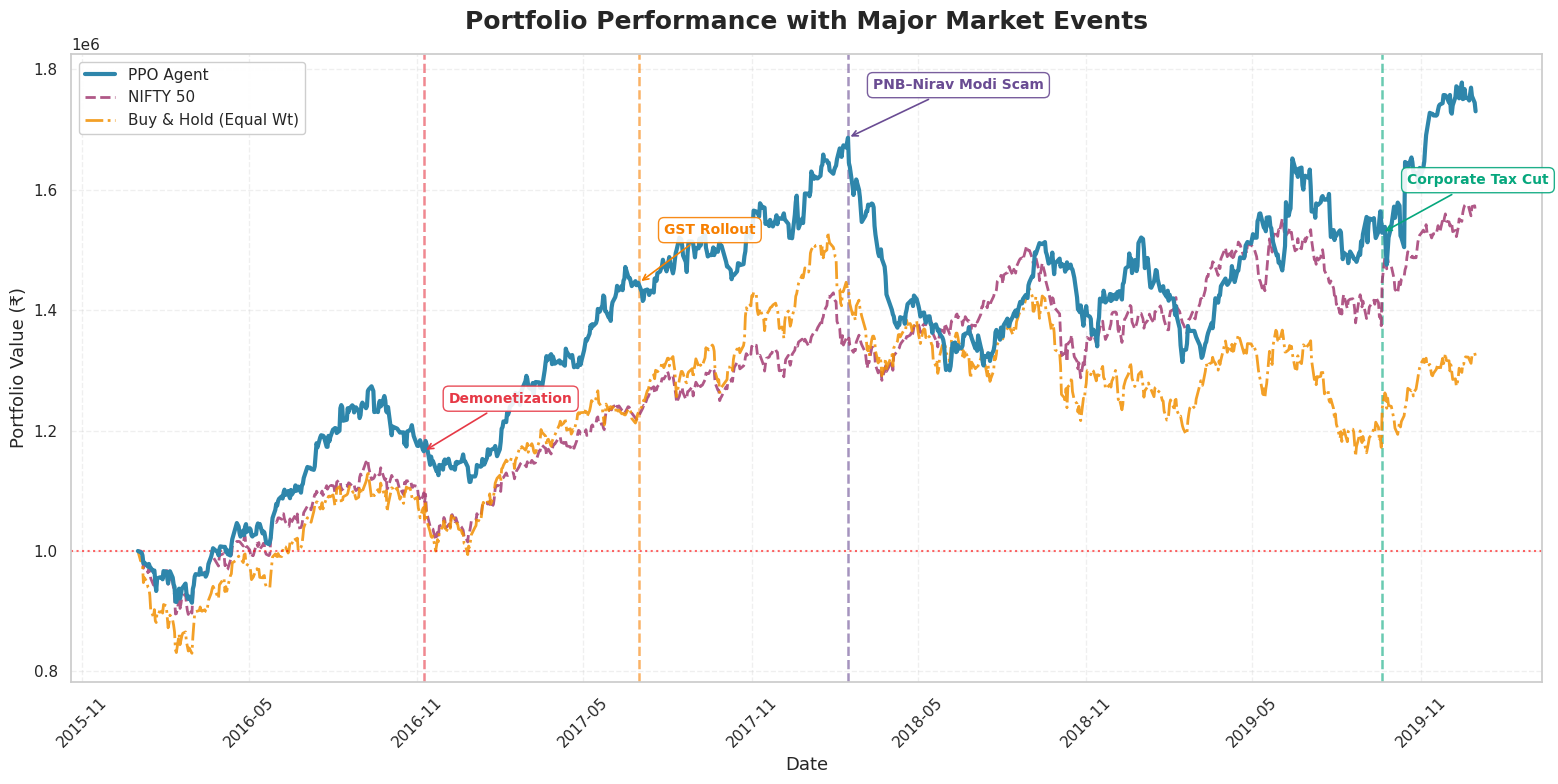

In [32]:
fig, ax = plt.subplots(figsize=(16, 8))

# --- Plot strategies (performance remains dominant) ---
ax.plot(df_agent['date'], df_agent['value'],
        label='PPO Agent', linewidth=3, color='#2E86AB', zorder=3)

ax.plot(df_nifty['date'], df_nifty['value'],
        label='NIFTY 50', linestyle='--', linewidth=2,
        color='#A23B72', alpha=0.85, zorder=2)

ax.plot(df_buyhold['date'], df_buyhold['value'],
        label='Buy & Hold (Equal Wt)', linestyle='-.', linewidth=2,
        color='#F18F01', alpha=0.85, zorder=2)

# --- Initial capital reference ---
ax.axhline(CONFIG['INITIAL_BALANCE'],
           color='red', linestyle=':', linewidth=1.5, alpha=0.6)

for event in MAJOR_EVENTS:
    event_date = pd.to_datetime(event['date'])
    if df_agent['date'].min() <= event_date <= df_agent['date'].max():

        # vertical marker
        ax.axvline(event_date,
                   color=event['color'],
                   linestyle='--',
                   linewidth=1.8,
                   alpha=0.6,
                   zorder=1)

        # anchor annotation to last known agent value
        y_val = df_agent.loc[df_agent['date'] <= event_date, 'value'].iloc[-1]

        ax.annotate(
            event['name'],
            xy=(event_date, y_val),
            xytext=(18, 35),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold',
            color=event['color'],
            bbox=dict(
                boxstyle='round,pad=0.4',
                fc='white',
                ec=event['color'],
                alpha=0.9
            ),
            arrowprops=dict(
                arrowstyle='->',
                color=event['color'],
                lw=1.2
            )
        )

# -----------------------------------------------------------------------------
# Styling & formatting
# -----------------------------------------------------------------------------
ax.set_title('Portfolio Performance with Major Market Events',
             fontsize=18, fontweight='bold', pad=18)

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Portfolio Value (₹)', fontsize=13)

ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##8.6 Out-of-Distribution Testing: US Market Performance

###8.6.1 US Stock Data Acquisition

In [33]:
US_40_STOCKS = {
    "Apple": "AAPL",  "Microsoft": "MSFT", "Amazon": "AMZN", "Alphabet": "GOOGL",
    "Meta": "META", "NVIDIA": "NVDA", "Tesla": "TSLA", "Berkshire Hathaway": "BRK-B",
    "JPMorgan Chase": "JPM", "Visa": "V", "Mastercard": "MA", "Johnson & Johnson": "JNJ",
    "UnitedHealth": "UNH", "Procter & Gamble": "PG", "Coca-Cola": "KO", "PepsiCo": "PEP",
    "Walmart": "WMT", "Home Depot": "HD", "Costco": "COST", "Exxon Mobil": "XOM",
    "Chevron": "CVX", "Pfizer": "PFE", "AbbVie": "ABBV", "Merck": "MRK", "Broadcom": "AVGO",
    "Adobe": "ADBE", "Netflix": "NFLX", "Salesforce": "CRM", "Intel": "INTC", "AMD": "AMD",
    "Cisco": "CSCO", "IBM": "IBM", "Oracle": "ORCL", "AT&T": "T", "Verizon": "VZ",
    "Goldman Sachs": "GS", "Morgan Stanley": "MS", "American Express": "AXP", "Nike": "NKE",
    "McDonald's": "MCD"
}

In [34]:
US_DATE_START = "2016-01-01"
US_DATE_END = "2019-12-31"

In [35]:
# DOWNLOAD US STOCK DATA
us_data = download_stock_data(
    tickers_dict=US_40_STOCKS,
    start_date = US_DATE_START,
    end_date=US_DATE_END,
    sleep_time=0.01
)

print(f"Downloaded US data for {us_data['company_name'].nunique()} stocks")




Data Summary
------------------------------------------------------------
Downloaded stocks : 40
Failed stocks     : 0
Total rows        : 40,200
Date range        : 2016-01-04 00:00:00 → 2019-12-30 00:00:00
------------------------------------------------------------
Downloaded US data for 40 stocks


##8.6.2 Model Evaluation on US Data

In [36]:
def run_out_of_distribution_test(
    model,
    data_df,
    rolling_split_dates,
    all_companies,
    initial_balance,
    reference_df=None
):
    """
    Run rolling-window evaluation on unseen market data
    using a frozen trained model.

    Parameters
    ----------
    model : trained PPO model (frozen)
    data_df : DataFrame (foreign market data)
    rolling_split_dates : list of pd.Timestamp
    all_companies : list of stock names (length = 40)
    initial_balance : float
    reference_df : DataFrame or None
        Used only for turbulence reference (optional)

    Returns
    -------
    all_dates, all_portfolio_values, all_cash_values
    """

    all_dates = []
    all_portfolio_values = []
    all_cash_values = []

    current_balance = initial_balance
    current_holdings = None

    for i in range(len(rolling_split_dates) - 1):

        test_start = rolling_split_dates[i]
        test_end = rolling_split_dates[i + 1]

        print(f"\nTesting window: {test_start.date()} → {test_end.date()}")

        # Store initial balance for this window to calculate return later
        window_initial_balance = current_balance

        # Prepare testing data
        trade_df = prepare_dataframe_for_window(
            data_df,
            test_start,
            test_end,
            all_companies
        )

        if trade_df.empty:
            print("Warning: Trading data empty, skipping window")
            continue


        # Turbulence
        if reference_df is not None:
            trade_turbulence, _ = calculate_turbulence_vectorized(
                trade_df,
                reference_df=reference_df
            )
            turbulence_threshold = None
        else:
            trade_turbulence, turbulence_threshold = calculate_turbulence_vectorized(
                trade_df
            )

        # Create trading environment
        env_trade = StockTradingEnv(
            df=trade_df,
            turbulence_array=trade_turbulence,
            turbulence_threshold=turbulence_threshold,
            initial_balance=current_balance,
            initial_holdings=current_holdings,
            h_max=CONFIG['H_MAX'],
            norm_dict=None
        )

        obs, _ = env_trade.reset(SEED)
        done = False

        # Pure evaluation loop
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env_trade.step(action)
            done = terminated or truncated

        # Collect window results
        window_values = env_trade.asset_memory
        window_cash = env_trade.cash_memory
        window_dates = sorted(trade_df['date'].unique())

        all_portfolio_values.extend(window_values[1:])
        all_cash_values.extend(window_cash[1:])
        all_dates.extend(window_dates)

        current_balance = window_values[-1]
        current_holdings = None  # liquidated between windows

        # Calculate window return
        if window_initial_balance != 0:
            win_ret = ((current_balance - window_initial_balance) / window_initial_balance) * 100
        else:
            win_ret = 0.0 # Handle division by zero if initial balance is 0

        print(f"Window final value: ₹{current_balance:,.2f} (Return: {win_ret:,.2f}%)")

    return all_dates, all_portfolio_values, all_cash_values

##8.6.3 Cross-Market Performance Comparison

In [37]:
all_companies_us = sorted(us_data['company_name'].unique())

# Generate rolling dates
rolling_split_dates_us = get_rolling_dates(US_DATE_START, US_DATE_END, freq='3ME')

all_portfolio_values_us = []
all_dates_us = []
all_cash_values_us = [] # Initialize all_cash_values

# Keep track of holdings between windows
current_holdings_us = None

In [38]:
us_data_with_indicators = (
    us_data
    .groupby('company_name', group_keys=False)
    .apply(calculate_ta_indicators)
    .reset_index(level=0)
)

us_data_processed = us_data_with_indicators.copy()
# Calculate daily returns for US data before dropping NaNs
us_data_processed['daily_return'] = us_data_processed.groupby('company_name')['close'].pct_change()
us_data_processed.dropna(inplace=True)

required_us_columns = [
    'date', 'company_name', 'close',
    'daily_return', 'MACD', 'RSI', 'CCI', 'ADX'
]

us_data_processed = us_data_processed[required_us_columns]

us_data_processed.sort_values(['date', 'company_name'], inplace=True);
us_data_processed.reset_index(drop=True, inplace=True);

print(f"Processed US data shape: {us_data_processed.shape}")
print(f"Processed US data date range: {us_data_processed['date'].min()} to {us_data_processed['date'].max()}")


all_dates_us, all_portfolio_values_us, all_cash_values_us = run_out_of_distribution_test(
    model=model,
    data_df=us_data_processed, # Use the processed US data
    rolling_split_dates=rolling_split_dates_us,
    all_companies=all_companies_us,
    initial_balance=CONFIG['INITIAL_BALANCE'],
    reference_df=None  # optional
)

Processed US data shape: (38680, 8)
Processed US data date range: 2016-02-29 00:00:00 to 2019-12-30 00:00:00

Testing window: 2016-01-31 → 2016-04-30
Window final value: ₹1,057,748.95 (Return: 5.77%)

Testing window: 2016-04-30 → 2016-07-31
Window final value: ₹1,094,248.94 (Return: 3.45%)

Testing window: 2016-07-31 → 2016-10-31
Window final value: ₹1,090,313.99 (Return: -0.36%)

Testing window: 2016-10-31 → 2017-01-31
Window final value: ₹1,176,219.61 (Return: 7.88%)

Testing window: 2017-01-31 → 2017-04-30
Window final value: ₹1,207,116.14 (Return: 2.63%)

Testing window: 2017-04-30 → 2017-07-31
Window final value: ₹1,213,597.83 (Return: 0.54%)

Testing window: 2017-07-31 → 2017-10-31
Window final value: ₹1,307,863.85 (Return: 7.77%)

Testing window: 2017-10-31 → 2018-01-31
Window final value: ₹1,514,686.96 (Return: 15.81%)

Testing window: 2018-01-31 → 2018-04-30
Window final value: ₹1,514,324.71 (Return: -0.02%)

Testing window: 2018-04-30 → 2018-07-31
Window final value: ₹1,633,1

##8.6.4 PPO Agent Performance: India vs. US


Overall Total Returns:
PPO Agent (India): 72.99%
PPO Agent (US): 100.20%


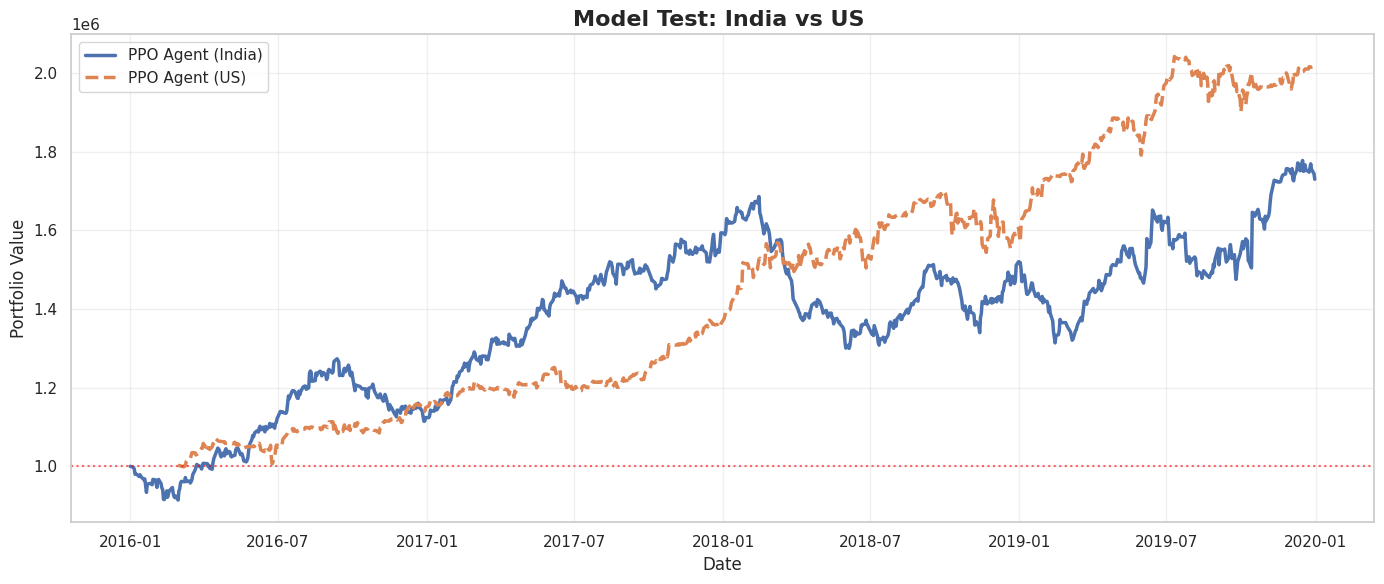

In [39]:
df_agent_us = pd.DataFrame({
    'date': pd.to_datetime(all_dates_us).normalize(),
    'value': all_portfolio_values_us
})

# Calculate and print overall returns
_, total_return_india, _, _, _ = calculate_performance_metrics(df_agent, CONFIG['INITIAL_BALANCE'], CONFIG['RISK_FREE_RATE_ANNUAL'])
_, total_return_us, _, _, _ = calculate_performance_metrics(df_agent_us, CONFIG['INITIAL_BALANCE'], CONFIG['RISK_FREE_RATE_ANNUAL'])

print("\nOverall Total Returns:")
print(f"PPO Agent (India): {total_return_india:.2f}%")
print(f"PPO Agent (US): {total_return_us:.2f}%")

plt.figure(figsize=(14, 6))

plt.plot(df_agent['date'], df_agent['value'],
         label='PPO Agent (India)', linewidth=2.5)

plt.plot(df_agent_us['date'], df_agent_us['value'],
         label='PPO Agent (US)', linewidth=2.5, linestyle='--')

plt.axhline(CONFIG['INITIAL_BALANCE'],
            color='red', linestyle=':', alpha=0.6)

plt.title('Model Test: India vs US ', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()